# 🤖 Notebook 4 — Model Training & Validation
**Project**: LLM Response Preference Predictor  

**Canonical training script:** `scripts/train.py`. This notebook mirrors Stages **5–8C**; keep splits, baselines, and saves aligned when the script changes. **TF-IDF width** is inferred from `X.shape[1] - scaler.n_features_in_` (109 dense features in the current pipeline).

---
### What this notebook covers
- Train/Test split (stratified)
- 4 baseline models: SGD, ComplementNB, LogisticRegression
- 3-Fold Cross-Validation with log-loss + F1
- Hyperparameter tuning (GridSearchCV)
- Soft-voting ensemble
- Final evaluation + confusion matrix
- Save production model

**After training:** see **Notebook 05** (offline inference), **06** (FastAPI / `TestClient`), **07** (matrix-level engineering check).


In [12]:
import numpy as np
import pandas as pd
import scipy.sparse as sp
import joblib, os, time, warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.naive_bayes import ComplementNB
from sklearn.metrics import (log_loss, accuracy_score, f1_score,
                              classification_report, confusion_matrix)

os.makedirs('../model', exist_ok=True)
sns.set_theme(style='whitegrid')
print('Libraries loaded ✓')

Libraries loaded ✓


In [13]:
# Feature layout mirrors scripts/train.py Stage 5 (TF-IDF columns first, then dense).
X = sp.load_npz('../artifacts/X_combined.npz')
y = np.load('../artifacts/y_labels.npy')
scaler = joblib.load('../artifacts/scaler.pkl')

n_dense = int(scaler.n_features_in_)  # dense columns (109 with current pipeline)
n_tfidf = X.shape[1] - n_dense
X_tfidf = X[:, :n_tfidf]            # NB / TF-IDF-only slice (non-negative sparse block)

label_names = ['Model A Wins', 'Model B Wins', 'Tie']
print(f'X: {X.shape}  y: {y.shape}  classes: {np.bincount(y)}')

X: (57477, 45023)  y: (57477,)  classes: [20064 19652 17761]


## 4.1 Train/Test Split

**Why stratified?** Ensures train and test have the same 35/34/31% class ratio.  
**Why 80/20?** 11.5k test rows gives a reliable performance estimate.

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
X_tfidf_train, X_tfidf_test, _, _ = train_test_split(
    X_tfidf, y, test_size=0.20, random_state=42, stratify=y
)

print(f'Train: {X_train.shape[0]:,} rows   Test: {X_test.shape[0]:,} rows')
for split, sy in [('Train', y_train), ('Test', y_test)]:
    c = np.bincount(sy); r = c / c.sum()
    print(f'  {split}: ' + ' | '.join(f'{label_names[i]}={r[i]*100:.1f}%' for i in range(3)))

Train: 45,981 rows   Test: 11,496 rows
  Train: Model A Wins=34.9% | Model B Wins=34.2% | Tie=30.9%
  Test: Model A Wins=34.9% | Model B Wins=34.2% | Tie=30.9%


## 4.2 Baseline Model Training

| Model | Strength | Note |
|---|---|---|
| SGDClassifier | Fast, large sparse data | Same math as LogReg, stochastic |
| ComplementNB | Imbalanced text datasets | Needs non-negative features |
| LogisticRegression | Best probability calibration | Slower but reliable |

In [15]:
baseline_specs = [
    ('SGD_logloss',  SGDClassifier(loss='log_loss', alpha=1e-4, class_weight='balanced',
                                   max_iter=200, random_state=42, n_jobs=1),
     X_train, X_test),
    ('SGD_huber',    SGDClassifier(loss='modified_huber', alpha=1e-4, class_weight='balanced',
                                   max_iter=200, random_state=42, n_jobs=1),
     X_train, X_test),
    ('ComplementNB', ComplementNB(alpha=0.1),
     X_tfidf_train, X_tfidf_test),
    ('LogReg',       LogisticRegression(C=1.0, solver='lbfgs', class_weight='balanced',
                                        max_iter=500, random_state=42, n_jobs=1),
     X_train, X_test),
]

baseline_results = {}
for name, model, Xtr, Xte in baseline_specs:
    t1 = time.time()
    model.fit(Xtr, y_train)
    pred  = model.predict(Xte)
    proba = model.predict_proba(Xte)
    ll  = log_loss(y_test, proba)
    f1  = f1_score(y_test, pred, average='macro')
    acc = accuracy_score(y_test, pred)
    baseline_results[name] = {'model':model,'ll':ll,'f1':f1,'acc':acc,'Xtr':Xtr,'Xte':Xte}
    print(f'[{name:<15}]  log-loss={ll:.4f}  F1={f1:.4f}  acc={acc*100:.2f}%  t={time.time()-t1:.0f}s')

[SGD_logloss    ]  log-loss=1.0583  F1=0.4565  acc=46.24%  t=7s
[SGD_huber      ]  log-loss=7.3244  F1=0.4251  acc=42.60%  t=12s
[ComplementNB   ]  log-loss=1.1110  F1=0.3779  acc=37.94%  t=0s
[LogReg         ]  log-loss=1.1175  F1=0.4236  acc=42.41%  t=85s


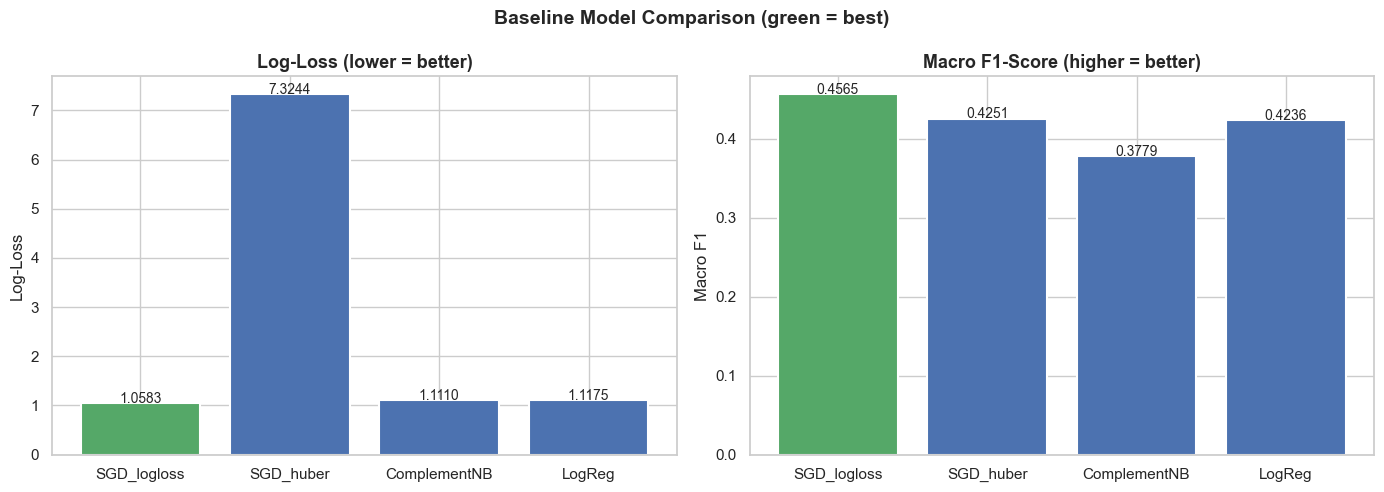

In [16]:
# Visualise baseline comparison
names = list(baseline_results.keys())
lls   = [baseline_results[n]['ll'] for n in names]
f1s   = [baseline_results[n]['f1'] for n in names]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#4C72B0'] * len(names)
colors[lls.index(min(lls))] = '#55A868'  # highlight best

axes[0].bar(names, lls, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Log-Loss (lower = better)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Log-Loss')
for i, v in enumerate(lls):
    axes[0].text(i, v + 0.002, f'{v:.4f}', ha='center', fontsize=10)

axes[1].bar(names, f1s, color=colors, edgecolor='white', linewidth=1.5)
axes[1].set_title('Macro F1-Score (higher = better)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Macro F1')
for i, v in enumerate(f1s):
    axes[1].text(i, v + 0.001, f'{v:.4f}', ha='center', fontsize=10)

plt.suptitle('Baseline Model Comparison (green = best)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/model_baseline_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 4.3 Cross-Validation

**Why CV?** A single split could be lucky/unlucky. 3-fold CV trains on 3 different partitions and averages — gives a more reliable estimate.  
**CV runs only on X_train** — X_test is never touched here.

In [17]:
cv3 = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

cv_candidates = [
    ('SGD_logloss',  SGDClassifier(loss='log_loss', alpha=1e-4, class_weight='balanced',
                                   max_iter=200, random_state=42, n_jobs=1), X_train),
    ('ComplementNB', ComplementNB(alpha=0.1), X_tfidf_train),
    ('LogReg',       LogisticRegression(C=1.0, solver='lbfgs', class_weight='balanced',
                                        max_iter=500, random_state=42, n_jobs=1), X_train),
]

cv_results = {}
print(f'{"Model":<15} {"CV LL":>8} {"± std":>8} {"CV F1":>8} {"time":>6}')
print('-' * 50)
for name, model, Xtr in cv_candidates:
    t1 = time.time()
    scores = cross_validate(
        model, Xtr, y_train,
        cv=cv3,
        scoring={'log_loss': 'neg_log_loss', 'f1_macro': 'f1_macro'},
        n_jobs=1,
    )
    ll_m = -scores['test_log_loss'].mean()
    ll_s =  scores['test_log_loss'].std()
    f1_m =  scores['test_f1_macro'].mean()
    cv_results[name] = {'ll_mean': ll_m, 'll_std': ll_s, 'f1_mean': f1_m}
    print(f'{name:<15} {ll_m:>8.4f} {ll_s:>8.4f} {f1_m:>8.4f} {time.time()-t1:>5.0f}s')
    print(f'  Per-fold LL: {[round(-v, 4) for v in scores["test_log_loss"]]}')

Model              CV LL    ± std    CV F1   time
--------------------------------------------------
SGD_logloss       1.0820   0.0068   0.4299    20s
  Per-fold LL: ['--1.084', '--1.0891', '--1.0728']
ComplementNB      1.1151   0.0008   0.3785     1s
  Per-fold LL: ['--1.1158', '--1.1155', '--1.1141']
LogReg            1.1266   0.0066   0.4218   269s
  Per-fold LL: ['--1.1319', '--1.1173', '--1.1307']


## 4.4 Hyperparameter Tuning

In [18]:
cv2 = StratifiedKFold(n_splits=2, shuffle=True, random_state=42)

# Tune SGD
print('Tuning SGDClassifier...')
sgd_grid = GridSearchCV(
    SGDClassifier(loss='log_loss', class_weight='balanced', max_iter=200, random_state=42),
    param_grid={'alpha': [1e-5, 5e-5, 1e-4, 5e-4, 1e-3]},
    scoring='neg_log_loss', cv=cv2, n_jobs=1, refit=True
)
sgd_grid.fit(X_train, y_train)
print(f'  Best alpha={sgd_grid.best_params_}  CV LL={-sgd_grid.best_score_:.4f}')

# Tune NB
print('Tuning ComplementNB...')
nb_grid = GridSearchCV(
    ComplementNB(),
    param_grid={'alpha': [0.01, 0.05, 0.1, 0.3, 0.5, 1.0]},
    scoring='neg_log_loss', cv=cv2, n_jobs=1, refit=True
)
nb_grid.fit(X_tfidf_train, y_train)
print(f'  Best alpha={nb_grid.best_params_}  CV LL={-nb_grid.best_score_:.4f}')

# Tune LogReg
print('Tuning LogisticRegression...')
lr_grid = GridSearchCV(
    LogisticRegression(solver='lbfgs', class_weight='balanced', max_iter=500, random_state=42),
    param_grid={'C': [0.05, 0.1, 0.5, 1.0, 3.0, 5.0]},
    scoring='neg_log_loss', cv=cv2, n_jobs=1, refit=True
)
lr_grid.fit(X_train, y_train)
print(f'  Best C={lr_grid.best_params_}  CV LL={-lr_grid.best_score_:.4f}')

Tuning SGDClassifier...
  Best alpha={'alpha': 0.001}  CV LL=1.0606
Tuning ComplementNB...
  Best alpha={'alpha': 1.0}  CV LL=1.1016
Tuning LogisticRegression...
  Best C={'C': 0.05}  CV LL=1.0528


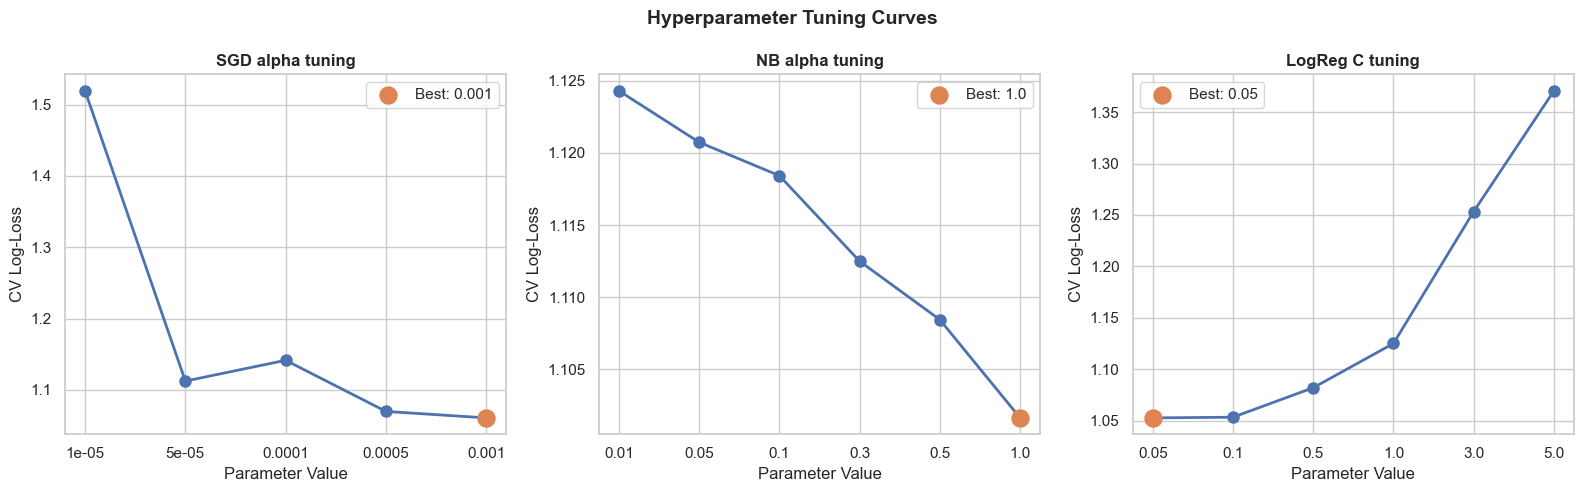

In [19]:
# Visualise tuning curves
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, grid, title in zip(axes,
    [sgd_grid, nb_grid, lr_grid],
    ['SGD alpha', 'NB alpha', 'LogReg C']):
    params = [str(list(p.values())[0]) for p in grid.cv_results_['params']]
    scores = -grid.cv_results_['mean_test_score']
    ax.plot(params, scores, 'o-', color='#4C72B0', linewidth=2, markersize=8)
    best_idx = scores.argmin()
    ax.scatter([params[best_idx]], [scores[best_idx]], color='#DD8452', s=150, zorder=5, label=f'Best: {params[best_idx]}')
    ax.set_title(f'{title} tuning', fontsize=12, fontweight='bold')
    ax.set_xlabel('Parameter Value')
    ax.set_ylabel('CV Log-Loss')
    ax.legend()

plt.suptitle('Hyperparameter Tuning Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/hyperparameter_tuning.png', dpi=150, bbox_inches='tight')
plt.show()

## 4.5 Ensemble + Final Evaluation

In [20]:
best_sgd = sgd_grid.best_estimator_
best_nb  = nb_grid.best_estimator_
best_lr  = lr_grid.best_estimator_

# Inverse-LL weights
ll_sgd, ll_nb, ll_lr = -sgd_grid.best_score_, -nb_grid.best_score_, -lr_grid.best_score_
w_sgd, w_nb, w_lr = 1/ll_sgd, 1/ll_nb, 1/ll_lr
total = w_sgd + w_nb + w_lr
w_sgd, w_nb, w_lr = w_sgd/total, w_nb/total, w_lr/total

print(f'Ensemble weights: SGD={w_sgd:.3f}  NB={w_nb:.3f}  LR={w_lr:.3f}')

p_sgd = best_sgd.predict_proba(X_test)
p_nb  = best_nb.predict_proba(X_tfidf_test)
p_lr  = best_lr.predict_proba(X_test)
p_ens = w_sgd*p_sgd + w_nb*p_nb + w_lr*p_lr

candidates = {
    'SGD (tuned)'     : (p_sgd, best_sgd.predict(X_test)),
    'NB (tuned)'      : (p_nb,  best_nb.predict(X_tfidf_test)),
    'LogReg (tuned)'  : (p_lr,  best_lr.predict(X_test)),
    'Ensemble'        : (p_ens, np.argmax(p_ens, axis=1)),
}

eval_res = {}
print(f'\n{"Model":<22} {"Log-loss":>9} {"Macro-F1":>9} {"Accuracy":>9}')
print('-'*52)
for name, (proba, pred) in candidates.items():
    ll  = log_loss(y_test, proba)
    f1  = f1_score(y_test, pred, average='macro')
    acc = accuracy_score(y_test, pred)
    eval_res[name] = {'ll':ll,'f1':f1,'acc':acc,'proba':proba,'pred':pred}
    marker = ' ← BEST' if name == min(eval_res, key=lambda k: eval_res[k]['ll']) else ''
    print(f'{name:<22} {ll:>9.4f} {f1:>9.4f} {acc*100:>8.2f}%{marker}')

Ensemble weights: SGD=0.337  NB=0.324  LR=0.339

Model                   Log-loss  Macro-F1  Accuracy
----------------------------------------------------
SGD (tuned)               1.0615    0.4532    45.42% ← BEST
NB (tuned)                1.1018    0.3781    37.96%
LogReg (tuned)            1.0484    0.4698    47.25% ← BEST
Ensemble                  1.0546    0.4626    46.26%


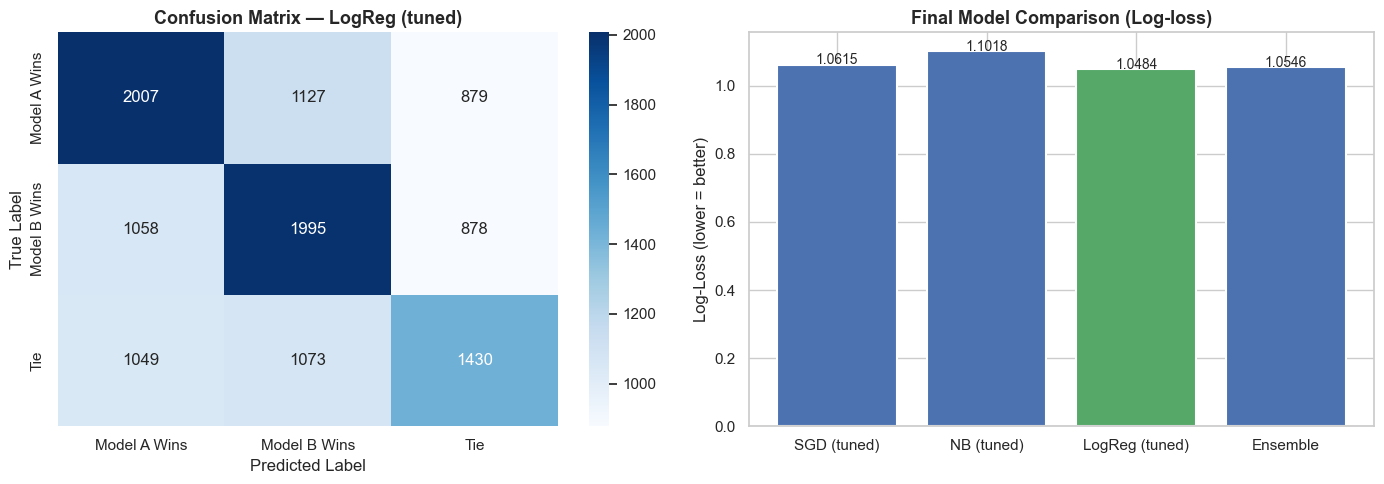


Classification Report (LogReg (tuned)):
              precision    recall  f1-score   support

Model A Wins       0.49      0.50      0.49      4013
Model B Wins       0.48      0.51      0.49      3931
         Tie       0.45      0.40      0.42      3552

    accuracy                           0.47     11496
   macro avg       0.47      0.47      0.47     11496
weighted avg       0.47      0.47      0.47     11496



In [21]:
# Confusion matrix for best model
winner = min(eval_res, key=lambda k: eval_res[k]['ll'])
wp = eval_res[winner]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, wp['pred'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names, yticklabels=label_names, ax=axes[0])
axes[0].set_title(f'Confusion Matrix — {winner}', fontsize=13, fontweight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# Log-loss comparison
names_e = list(eval_res.keys())
lls_e = [eval_res[n]['ll'] for n in names_e]
colors_e = ['#55A868' if n == winner else '#4C72B0' for n in names_e]
axes[1].bar(names_e, lls_e, color=colors_e, edgecolor='white', linewidth=1.5)
axes[1].set_title('Final Model Comparison (Log-loss)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Log-Loss (lower = better)')
for i, v in enumerate(lls_e):
    axes[1].text(i, v+0.001, f'{v:.4f}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('../data/final_model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nClassification Report ({winner}):')
print(classification_report(y_test, wp['pred'], target_names=label_names))

## 4.6 Retrain on Full Data + Save Production Model

In [ ]:
best_p_sgd = sgd_grid.best_params_
best_p_nb  = nb_grid.best_params_
best_p_lr  = lr_grid.best_params_

print(f'Retraining on full {X.shape[0]:,} rows with best params...')
final_sgd = SGDClassifier(loss='log_loss', alpha=best_p_sgd['alpha'],
                           class_weight='balanced', max_iter=200, random_state=42)
final_nb  = ComplementNB(alpha=best_p_nb['alpha'])
final_lr  = LogisticRegression(C=best_p_lr['C'], solver='lbfgs',
                                class_weight='balanced', max_iter=500, random_state=42)

t1 = time.time()
final_sgd.fit(X, y)
final_nb.fit(X_tfidf, y)
final_lr.fit(X, y)
print(f'Done in {time.time()-t1:.0f}s')

# Save models and weights
joblib.dump(final_sgd, '../model/final_sgd.pkl')
joblib.dump(final_nb,  '../model/final_nb.pkl')
joblib.dump(final_lr,  '../model/final_logreg.pkl')
np.save('../model/ensemble_weights.npy', np.array([w_sgd, w_nb, w_lr]))

# Save model metadata
import json
metadata = {
    'best_params': {
        'sgd_alpha': best_p_sgd['alpha'],
        'nb_alpha':  best_p_nb['alpha'],
        'lr_C':      best_p_lr['C']
    },
    'ensemble_weights': {'sgd': w_sgd, 'nb': w_nb, 'lr': w_lr},
    'eval_log_loss':  wp['ll'],
    'eval_macro_f1':  wp['f1'],
    'eval_accuracy':  wp['acc'],
    'n_features': int(X.shape[1]),
    'n_tfidf_features': int(n_tfidf),
    'n_dense_features': int(n_dense),
    'dense_feature_names': list(pd.read_csv('../artifacts/dense_features.csv', nrows=0).columns),
    'label_map': {'0': 'Model A is better', '1': 'Model B is better', '2': 'Tie'},
    'trained_on_rows': int(X.shape[0]),
    'winner_model': winner,
}
with open('../model/model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print('\nSaved to ../model/')
print('  final_sgd.pkl, final_nb.pkl, final_logreg.pkl')
print('  ensemble_weights.npy, model_metadata.json')
print(f'\n✅ Best model: {winner}')
print(f'   Log-loss: {wp["ll"]:.4f}  F1: {wp["f1"]:.4f}  Accuracy: {wp["acc"]*100:.2f}%')

Retraining on full 57,477 rows with best params...
Done in 56s

Saved to ../model/
  final_sgd.pkl, final_nb.pkl, final_logreg.pkl
  ensemble_weights.npy, model_metadata.json

✅ Best model: LogReg (tuned)
   Log-loss: 1.0484  F1: 0.4698  Accuracy: 47.25%


: 